# Case A : Data only for dt=0.5

In [2]:
# Imports
import os
import time
import psutil
import random
import warnings
import csv

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve
from scipy.optimize import minimize

tf.config.set_visible_devices([], 'GPU')

# CONFIG
TF64 = True

NX_COARSE = 11
NX_FINE   = 201

L  = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Adam
EPOCHS      = 2500
LR          = 5e-5

BETA_L2   = 1e-6
GRAD_CLIP = 1.0
PATIENCE  = 800

# L-BFGS
USE_LBFGS     = True
LBFGS_MAXITER = 300
LBFGS_FTOL    = 1e-10

# Output paths
CASE_NAME = "CaseA_DataOnly"

OUT_DIR = f"{CASE_NAME}_results"
os.makedirs(OUT_DIR, exist_ok=True)

PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseA_dataonly.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseA_dataonly_meta.npz"
)

DATA_FILE = os.path.join(
    OUT_DIR,
    "training_pairs.npz"
)

METRICS_FILE = os.path.join(
    OUT_DIR,
    "timing_metrics.csv"
)

# Reproducibility
if TF64:
    tf.keras.backend.set_floatx("float64")

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")

# Memory
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

print("\nCONFIG LOADED")

print("Initial memory usage: %.2f MB" % memory_mb())

# Differentiation Matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

D_tf = tf.constant(D_np, dtype=tf.float64)

# Residual
def residual_np(y, u):

    return y - u + 0.25*DT*(D_np @ (y**2))

@tf.function
def residual_tf(y, u):

    y_sq = tf.square(y)

    dy_dx = tf.linalg.matmul(
        y_sq,
        tf.transpose(D_tf)
    )

    return y - u + 0.25*DT*dy_dx
    
# Grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Fourier Interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left  = pad_total // 2
    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# FSolve
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol, info, ier, msg = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12,
        maxfev=30000,
        full_output=True
    )

    if ier != 1:
        print("[warn fsolve]", msg)

    return y_sol.astype(np.float64)

# Training functions
def make_rich_family():

    fns = []
    
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]
    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns = make_rich_family()

print("Training family size:", len(train_fns))

# Generate/load data
if os.path.exists(DATA_FILE):

    dd = np.load(DATA_FILE, allow_pickle=True)

    un_train = dd["un"]

    y1_train = dd["y1"]

    print("Loaded cached data:", un_train.shape)

else:

    print("\nGenerating fsolve training data...")

    U_list = []
    Y_list = []

    for i, (name, fn) in enumerate(train_fns):

        u_c = fn(x_coarse)

        u_f = fourier_interpolate(
            u_c,
            NX_COARSE,
            NX_FINE
        )

        y1 = compute_y1_fsolve(u_f)

        U_list.append(u_f)

        Y_list.append(y1)

        print(f"{i+1}/{len(train_fns)} -> {name}")

    un_train = np.array(U_list)

    y1_train = np.array(Y_list)

    np.savez(
        DATA_FILE,
        un=un_train,
        y1=y1_train
    )

# Features
def build_features(un_batch):

    mag = np.abs(
        np.fft.fft(un_batch, axis=-1)
    )[:, :NX_FINE//2+1]

    mag = 0.2 * mag

    return np.concatenate(
        [un_batch, mag],
        axis=-1
    )

X_raw = build_features(un_train)

feat_mean = np.mean(X_raw, axis=0)

feat_std = np.std(X_raw, axis=0) + 1e-12

X_norm = (X_raw - feat_mean) / feat_std

print("\nFeature shape:", X_norm.shape)

# Siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0 / in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Model
def build_model():

    input_dim = X_norm.shape[1]

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

print(model.count_params(), "parameters")

# into sensors
X_tf = tf.convert_to_tensor(
    X_norm,
    dtype=tf.float64
)

Y_tf = tf.convert_to_tensor(
    y1_train,
    dtype=tf.float64
)

optimizer = tf.keras.optimizers.Adam(LR)

# Training
print("\nSTART TRAINING")

train_start = time.perf_counter()

peak_memory_before = memory_mb()

best_total = np.inf

wait = 0

for epoch in range(1, EPOCHS+1):

    with tf.GradientTape() as tape:

        y_pred = model(X_tf, training=True)

        sup_loss = tf.reduce_mean(
            tf.square(y_pred - Y_tf)
        )

        reg = BETA_L2 * tf.add_n([

            tf.nn.l2_loss(v)

            for v in model.trainable_variables
        ])

        total = sup_loss + reg

    grads = tape.gradient(
        total,
        model.trainable_variables
    )

    grads = [

        tf.clip_by_norm(g, GRAD_CLIP)

        for g in grads
    ]

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    if epoch % 100 == 0 or epoch == 1:

        print(

            f"Epoch {epoch:4d} | "

            f"Total={float(total):.3e} | "

            f"Sup={float(sup_loss):.3e}"
        )

    total_val = float(total.numpy())

    if total_val < best_total:

        best_total = total_val

        wait = 0

        model.save_weights(WEIGHTS_FILE)

    else:

        wait += 1

        if wait >= PATIENCE:

            print("Early stopping.")

            break

train_end = time.perf_counter()

train_time_sec = train_end - train_start

peak_memory_after = memory_mb()

peak_memory_used = (
    peak_memory_after - peak_memory_before
)

print("\nTRAINING COMPLETE")

print("Training time: %.2f sec" % train_time_sec)

print("Memory increase: %.2f MB" % peak_memory_used)

# L-BFGS
if USE_LBFGS:

    print("\n=== PHASE 2: L-BFGS polish ===")

    model.load_weights(WEIGHTS_FILE)

    print("[L-BFGS] loaded best Adam weights")

    var_list = model.trainable_variables

    shapes = [v.shape for v in var_list]

    sizes = [int(np.prod(s)) for s in shapes]

    total_params = sum(sizes)

    print("[L-BFGS] total params =", total_params)

    def pack_weights():

        return np.concatenate([
            v.numpy().ravel()
            for v in var_list
        ])

    def unpack_weights(theta):

        offset = 0

        for v, s, sz in zip(
            var_list,
            shapes,
            sizes
        ):

            chunk = theta[offset:offset+sz]

            v.assign(chunk.reshape(s))

            offset += sz

    @tf.function
    def loss_and_grads_tf():

        with tf.GradientTape() as tape:

            y_pred = model(
                X_tf,
                training=True
            )

            sup_loss = tf.reduce_mean(
                tf.square(y_pred - Y_tf)
            )

            reg = BETA_L2 * tf.add_n([

                tf.nn.l2_loss(v)

                for v in model.trainable_variables
            ])

            total = sup_loss + reg

        grads = tape.gradient(
            total,
            var_list
        )

        return total, grads, sup_loss

    def lbfgs_objective(theta):

        unpack_weights(theta)

        total_tf, grads_tf, sup_tf = (
            loss_and_grads_tf()
        )

        loss_val = float(total_tf.numpy())

        grad_vec = np.concatenate([

            g.numpy().ravel()

            for g in grads_tf
        ])

        return loss_val, grad_vec

    theta0 = pack_weights()

    lbfgs_start = time.perf_counter()

    result = minimize(

        lbfgs_objective,

        theta0,

        jac=True,

        method='L-BFGS-B',

        options={

            'maxiter': LBFGS_MAXITER,

            'ftol': LBFGS_FTOL,

            'maxcor': 50,

            'iprint': 1
        }
    )

    lbfgs_end = time.perf_counter()

    lbfgs_time = lbfgs_end - lbfgs_start

    print("\n[L-BFGS] optimization finished")

    print("[L-BFGS] time: %.2f sec" % lbfgs_time)

    print("[L-BFGS] success:",
          result.success)

    print("[L-BFGS] message:",
          result.message)

    unpack_weights(result.x)

    total_tf, _, sup_tf = (
        loss_and_grads_tf()
    )

    print("\n[L-BFGS FINAL]")

    print(
        "Total = %.3e"
        % float(total_tf.numpy())
    )

    print(
        "Sup   = %.3e"
        % float(sup_tf.numpy())
    )

    model.save_weights(WEIGHTS_FILE)

    print("\n[L-BFGS] saved polished weights:")

    print(WEIGHTS_FILE)

# Save meta
np.savez(

    META_FILE,

    feat_mean=feat_mean,
    feat_std=feat_std,

    NX_FINE=NX_FINE,
    NX_COARSE=NX_COARSE,

    DT=DT,
    L=L,

    HIDDEN_UNITS=HIDDEN_UNITS,
    DEPTH=DEPTH,
    SIREN_W0=SIREN_W0
)

print("\nSaved weights:", WEIGHTS_FILE)

print("Saved meta:", META_FILE) 


CONFIG LOADED
Initial memory usage: 365.18 MB
Training family size: 88

Generating fsolve training data...
1/88 -> sin(1x)
2/88 -> cos(1x)
3/88 -> sin(2x)
4/88 -> cos(2x)
5/88 -> sin(3x)
6/88 -> cos(3x)
7/88 -> sin(4x)
8/88 -> cos(4x)
9/88 -> sin(5x)
10/88 -> cos(5x)
11/88 -> sin(6x)
12/88 -> cos(6x)
13/88 -> sin(7x)
14/88 -> cos(7x)
15/88 -> sin(8x)
16/88 -> cos(8x)
17/88 -> sin(9x)
18/88 -> cos(9x)
19/88 -> sin(10x)
20/88 -> cos(10x)
21/88 -> sin(11x)
22/88 -> cos(11x)
23/88 -> sin(12x)
24/88 -> cos(12x)
25/88 -> sin(1x+0.3)
26/88 -> sin(1x+0.7)
27/88 -> sin(1x+1.2)
28/88 -> sin(2x+0.3)
29/88 -> sin(2x+0.7)
30/88 -> sin(2x+1.2)
31/88 -> sin(3x+0.3)
32/88 -> sin(3x+0.7)
33/88 -> sin(3x+1.2)
34/88 -> sin(4x+0.3)
35/88 -> sin(4x+0.7)
36/88 -> sin(4x+1.2)
37/88 -> sin(5x+0.3)
38/88 -> sin(5x+0.7)
39/88 -> sin(5x+1.2)
40/88 -> sin(1.5x)
41/88 -> sin(2.5x)
42/88 -> sin(3.5x)
43/88 -> sin(4.5x)
44/88 -> sin^2(x)
45/88 -> cos^2(x)
46/88 -> sin^3(x)
47/88 -> cos^3(x)
48/88 -> sin+0.5sin2
49/

### Computational metrics

In [6]:
# LOAD SAVED MODEL
model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("Loaded saved model.")

# Feature builder
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# Test functions
tests =  [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),
    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    # Gaussian+irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),
    # Normalized poly
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2)
    ),
    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) 
    )
]


# Metrics
rows = []

for name, fn in tests:

    print("\n====================")

    print(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # NN
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # Fsolve
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Rollout
    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps=5)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # Residual
    r = residual_np(y_pred, uf)

    Linf = np.max(np.abs(r))

    Mean = np.mean(np.abs(r))

    # Memory
    mem_now = memory_mb()

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    print(f"Linf residual: {Linf:.3e}")

    rows.append([

        name,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now,

        Linf,

        Mean
    ])

# SAVE CSV
with open(METRICS_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB",

        "Linf",

        "MeanResidual"
    ])

    writer.writerows(rows)

print("\nSaved metrics CSV:")

print(METRICS_FILE)

Loaded saved model.

sin(x)
NN inference : 13.953 ms
fsolve solve : 37.089 ms
5-step rollout: 0.062 sec
Memory usage : 731.86 MB
Linf residual: 6.300e-03

0.5+0.25sin(x)
NN inference : 11.201 ms
fsolve solve : 29.107 ms
5-step rollout: 0.054 sec
Memory usage : 731.89 MB
Linf residual: 2.938e-01

sin(sqrt(2)x)
NN inference : 11.902 ms
fsolve solve : 37.873 ms
5-step rollout: 0.057 sec
Memory usage : 731.90 MB
Linf residual: 2.326e-01

cos(sqrt(3)x)
NN inference : 11.105 ms
fsolve solve : 34.553 ms
5-step rollout: 0.053 sec
Memory usage : 731.91 MB
Linf residual: 4.341e-01

exp(-(x-pi)^2)*sin(sqrt(2)x)
NN inference : 14.039 ms
fsolve solve : 36.433 ms
5-step rollout: 0.053 sec
Memory usage : 731.93 MB
Linf residual: 6.940e-01

((x-pi)^2)/(pi^2)
NN inference : 15.105 ms
fsolve solve : 32.393 ms
5-step rollout: 0.048 sec
Memory usage : 731.97 MB
Linf residual: 1.030e+01

(pi^2-(x-pi)^2)/(pi^2)
NN inference : 10.405 ms
fsolve solve : 38.426 ms
5-step rollout: 0.058 sec
Memory usage : 731.98

### Testing OOD


Loaded saved model.

TEST & DIAGNOSTICS

--- sin(x) ---
[test] sin(x)       | L∞=6.300e-03 | Mean=1.572e-03
NN inference : 10.765 ms
fsolve solve : 24.878 ms
5-step rollout: 0.036 sec
Memory usage : 888.57 MB


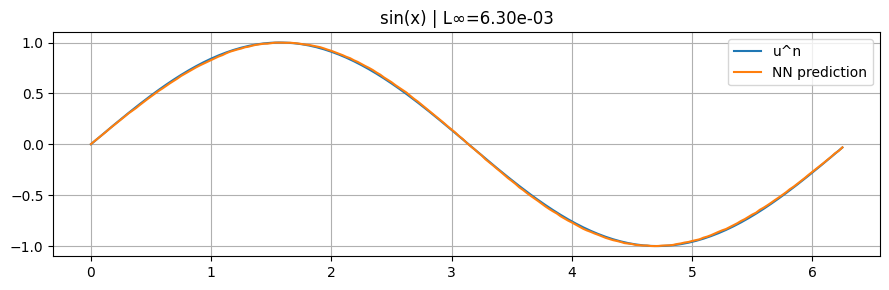

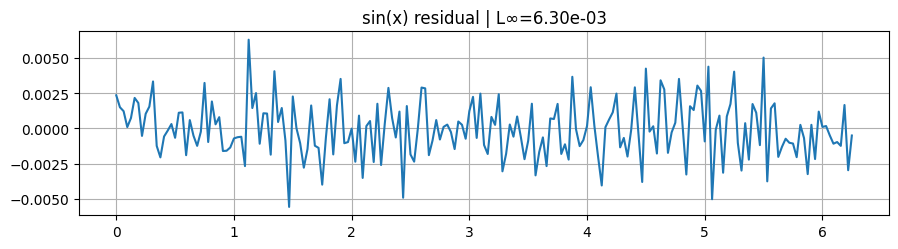

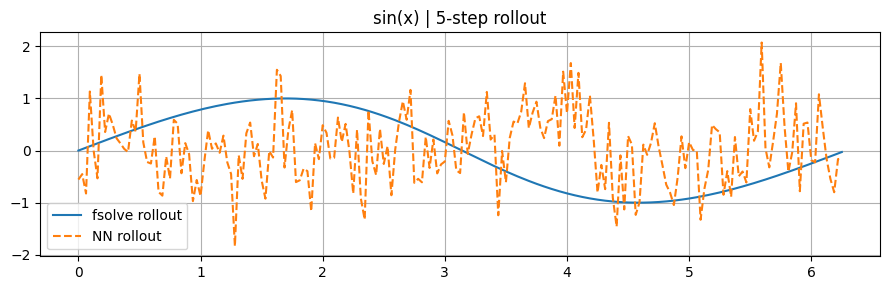


--- 0.5+0.25sin(x) ---
[test] 0.5+0.25sin(x) | L∞=2.938e-01 | Mean=1.051e-01
NN inference : 11.385 ms
fsolve solve : 24.099 ms
5-step rollout: 0.039 sec
Memory usage : 891.77 MB


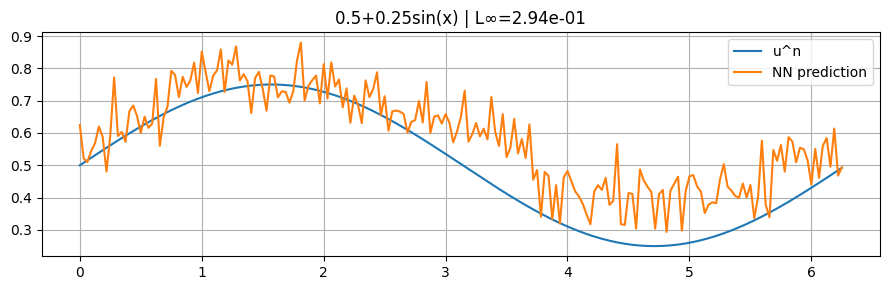

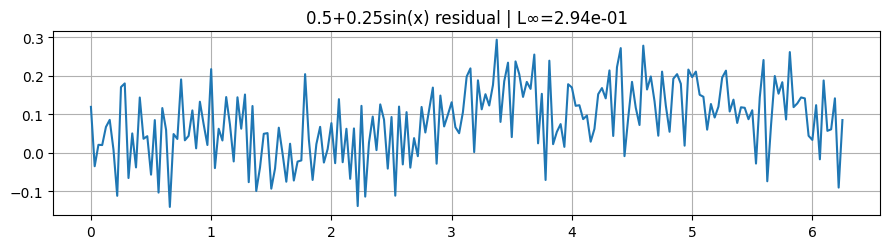

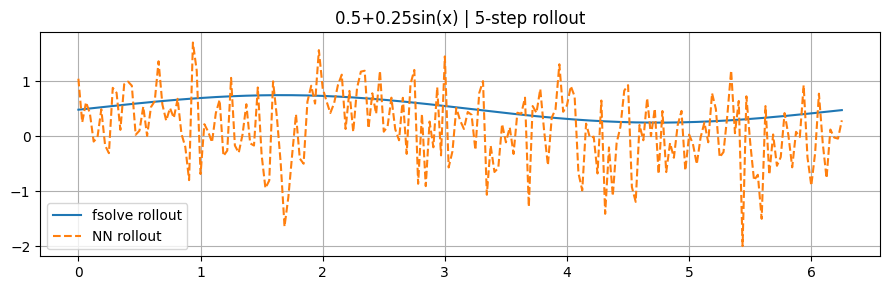


--- sin(sqrt(2)x) ---
[test] sin(sqrt(2)x) | L∞=2.326e-01 | Mean=6.151e-02
NN inference : 11.093 ms
fsolve solve : 44.168 ms
5-step rollout: 0.059 sec
Memory usage : 894.40 MB


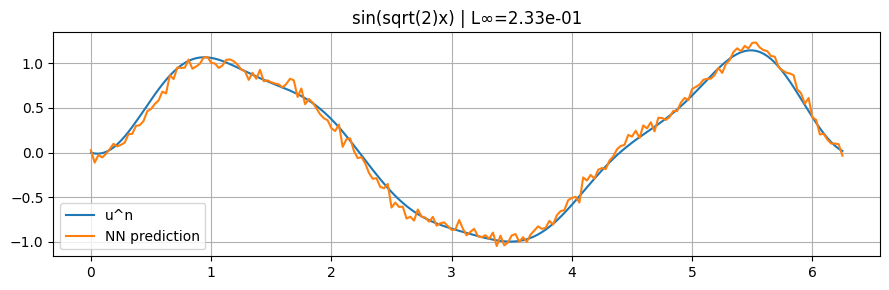

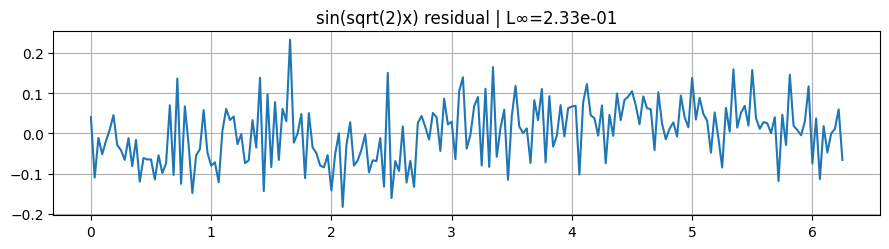

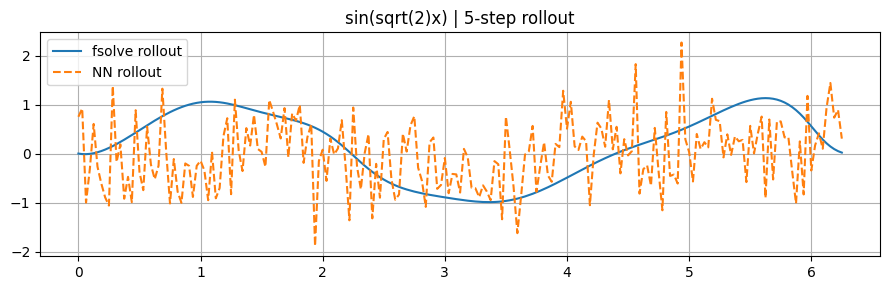


--- cos(sqrt(3)x) ---
[test] cos(sqrt(3)x) | L∞=4.341e-01 | Mean=1.216e-01
NN inference : 11.292 ms
fsolve solve : 36.322 ms
5-step rollout: 0.055 sec
Memory usage : 897.84 MB


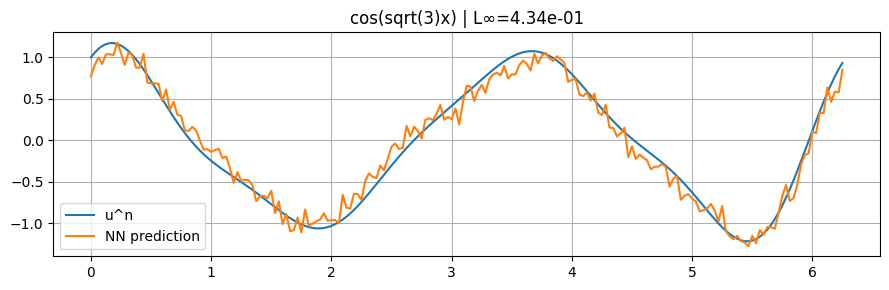

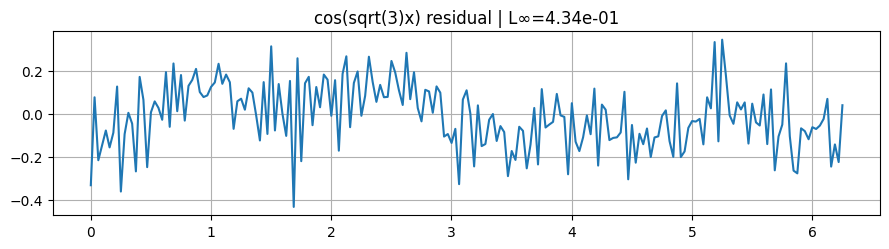

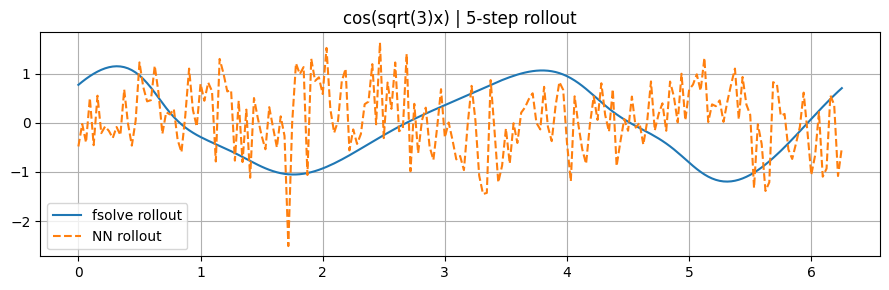


--- exp(-(x-pi)^2)*sin(sqrt(2)x) ---
[test] exp(-(x-pi)^2)*sin(sqrt(2)x) | L∞=6.940e-01 | Mean=1.876e-01
NN inference : 14.110 ms
fsolve solve : 40.129 ms
5-step rollout: 0.060 sec
Memory usage : 900.41 MB


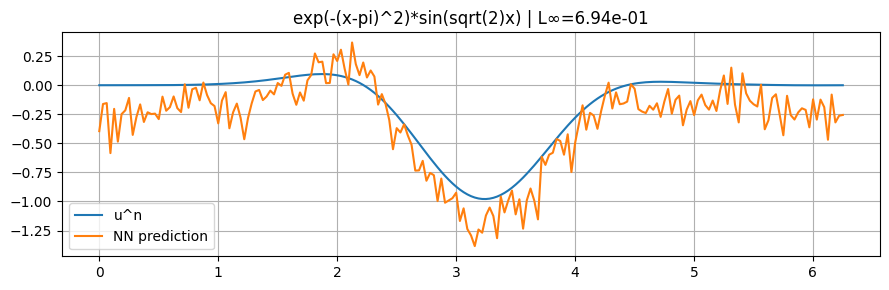

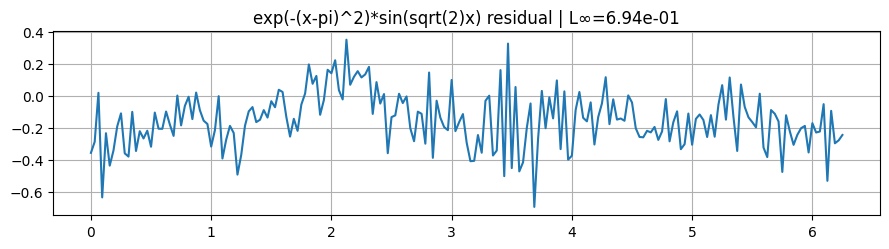

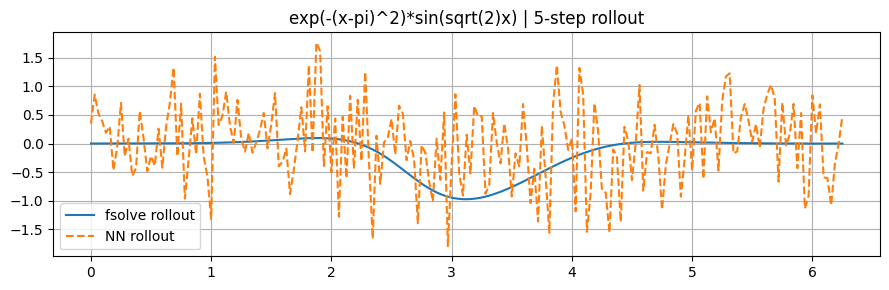


--- ((x-pi)^2)/(pi^2) ---
[test] ((x-pi)^2)/(pi^2) | L∞=3.066e-01 | Mean=8.574e-02
NN inference : 15.537 ms
fsolve solve : 42.070 ms
5-step rollout: 0.060 sec
Memory usage : 904.21 MB


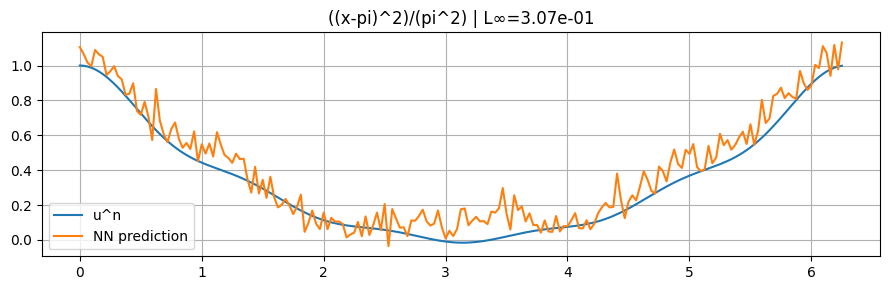

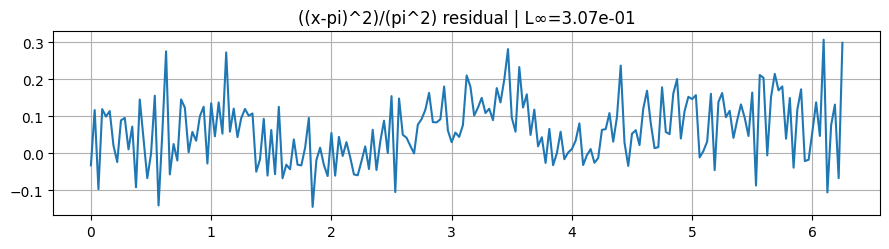

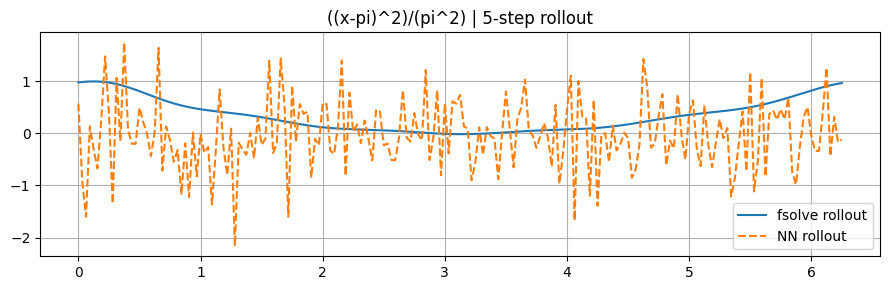


--- (pi^2-(x-pi)^2)/(pi^2) ---
[test] (pi^2-(x-pi)^2)/(pi^2) | L∞=4.674e-01 | Mean=1.456e-01
NN inference : 11.837 ms
fsolve solve : 38.864 ms
5-step rollout: 0.060 sec
Memory usage : 906.57 MB


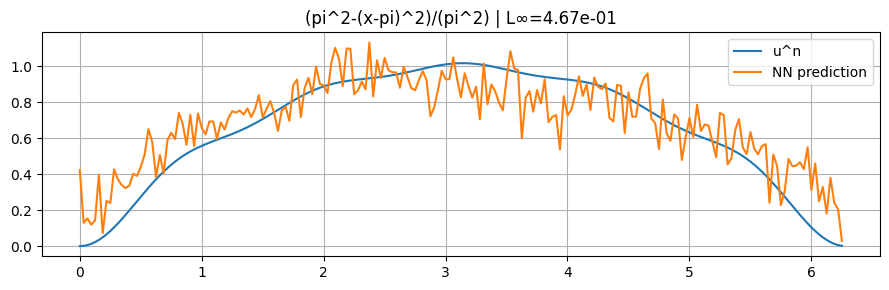

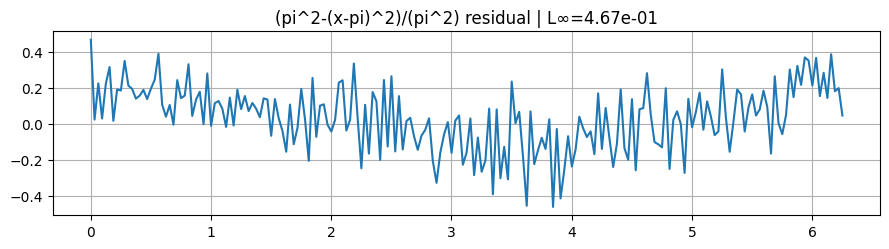

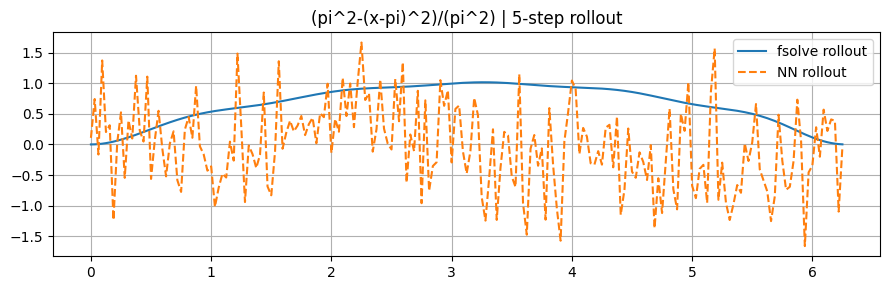


Saved summary CSV:
CaseA_DataOnly_results\testing_summary.csv

Plots saved in:
CaseA_DataOnly_results\plots


In [8]:
# TEST & DIAGNOSTICS (LOAD SAVED MODEL)
import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve

# Paths
OUT_DIR = "CaseA_DataOnly_results"

PLOTS_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseA_dataonly.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseA_dataonly_meta.npz"
)

CSV_FILE = os.path.join(
    OUT_DIR,
    "testing_summary.csv"
)

# Memory
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

# Load meta
meta = np.load(META_FILE, allow_pickle=True)

NX_FINE   = int(meta["NX_FINE"])

NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])

L  = float(meta["L"])

HIDDEN_UNITS = int(meta["HIDDEN_UNITS"])

DEPTH = int(meta["DEPTH"])

SIREN_W0 = float(meta["SIREN_W0"])

feat_mean = meta["feat_mean"]

feat_std = meta["feat_std"]

# Grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Diffferentiation matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

# Residual
def residual_np(y, u):

    return y - u + 0.25*DT*(D_np @ (y**2))

# Fourier Interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left = pad_total // 2

    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# Fsolve
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12
    )

    return y_sol.astype(np.float64)

# SIREN LAYER
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0/in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Model
def build_model():

    input_dim = len(feat_mean)

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, len(feat_mean)), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("\nLoaded saved model.")

# SAFE FILENAME
def safe_filename(name):

    return (
        name.replace("(", "")
            .replace(")", "")
            .replace("*", "")
            .replace("^", "")
            .replace("+", "")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("=", "_")
            .replace(" ", "_")
    )

# Features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# Testing function
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),

    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),
    # Normalised Polynomial
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) / (np.pi**2)
    )
]

summary = []

# Testing
print("\nTEST & DIAGNOSTICS")

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    # Initial conditions
    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # NN Prediciton TIMING
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # Fsolve timing
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Residual
    r = residual_np(y_pred, uf)

    Linf = float(np.max(np.abs(r)))

    Mean = float(np.mean(np.abs(r)))

    # Rollout timing
    steps = 5

    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # Rollout
    traj_fs = [uf.copy()]

    tmp = uf.copy()

    for _ in range(steps):

        tmp = compute_y1_fsolve(tmp)

        traj_fs.append(tmp.copy())

    mem_now = memory_mb()

    print(
        f"[test] {name:12s} | "
        f"L∞={Linf:.3e} | "
        f"Mean={Mean:.3e}"
    )

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    xs = x_fine

    # Sol. Plot
    plt.figure(figsize=(9,3))

    plt.plot(xs, uf, label="u^n")

    plt.plot(xs, y_pred, label="NN prediction")

    plt.legend()

    plt.title(f"{name} | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_nn.png"
        ),
        dpi=150
    )

    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))

    plt.plot(xs, r)

    plt.title(f"{name} residual | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_res.png"
        ),
        dpi=150
    )

    plt.show()

    # Rollout plot
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        traj_fs[-1],
        label="fsolve rollout"
    )

    plt.plot(
        xs,
        traj_nn[-1],
        "--",
        label="NN rollout"
    )

    plt.legend()

    plt.title(f"{name} | {steps}-step rollout")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_rollout.png"
        ),
        dpi=150
    )

    plt.show()

    summary.append([

        name,

        Linf,

        Mean,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now
    ]
                   
# SAVE CSV
with open(CSV_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Linf",

        "MeanResidual",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB"
    ])

    writer.writerows(summary)

print("\nSaved summary CSV:")

print(CSV_FILE)

print("\nPlots saved in:")

print(PLOTS_DIR)

# CASE 2 for dt=0.005

In [2]:
# Imports
import os
import time
import psutil
import random
import warnings
import csv

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve
from scipy.optimize import minimize

tf.config.set_visible_devices([], 'GPU')

# CONFIG
TF64 = True

NX_COARSE = 11
NX_FINE   = 201

L  = 2*np.pi
DT = 0.005

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Adam
EPOCHS      = 2500
LR          = 5e-5

BETA_L2   = 1e-6
GRAD_CLIP = 1.0
PATIENCE  = 800

# L-BFGS
USE_LBFGS     = True
LBFGS_MAXITER = 300
LBFGS_FTOL    = 1e-10

# Output paths
CASE_NAME = "CaseA_DataOnly_0.005"

OUT_DIR = f"{CASE_NAME}_results"
os.makedirs(OUT_DIR, exist_ok=True)

PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseA_dataonly_0.005.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseA_dataonly_meta_0.005.npz"
)

DATA_FILE = os.path.join(
    OUT_DIR,
    "training_pairs.npz_0.005"
)

METRICS_FILE = os.path.join(
    OUT_DIR,
    "timing_metrics_0.005.csv"
)

# Reproducibility
if TF64:
    tf.keras.backend.set_floatx("float64")

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")

# Memory
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

print("\nCONFIG LOADED")

print("Initial memory usage: %.2f MB" % memory_mb())

# Differentiation Matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

D_tf = tf.constant(D_np, dtype=tf.float64)

# Residual
def residual_np(y, u):

    return y - u + 0.25*DT*(D_np @ (y**2))

@tf.function
def residual_tf(y, u):

    y_sq = tf.square(y)

    dy_dx = tf.linalg.matmul(
        y_sq,
        tf.transpose(D_tf)
    )

    return y - u + 0.25*DT*dy_dx
    
# Grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Fourier Interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left  = pad_total // 2
    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# FSolve
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol, info, ier, msg = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12,
        maxfev=30000,
        full_output=True
    )

    if ier != 1:
        print("[warn fsolve]", msg)

    return y_sol.astype(np.float64)

# Training functions
def make_rich_family():

    fns = []
    
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]
    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns = make_rich_family()

print("Training family size:", len(train_fns))

# Generate/load data
if os.path.exists(DATA_FILE):

    dd = np.load(DATA_FILE, allow_pickle=True)

    un_train = dd["un"]

    y1_train = dd["y1"]

    print("Loaded cached data:", un_train.shape)

else:

    print("\nGenerating fsolve training data...")

    U_list = []
    Y_list = []

    for i, (name, fn) in enumerate(train_fns):

        u_c = fn(x_coarse)

        u_f = fourier_interpolate(
            u_c,
            NX_COARSE,
            NX_FINE
        )

        y1 = compute_y1_fsolve(u_f)

        U_list.append(u_f)

        Y_list.append(y1)

        print(f"{i+1}/{len(train_fns)} -> {name}")

    un_train = np.array(U_list)

    y1_train = np.array(Y_list)

    np.savez(
        DATA_FILE,
        un=un_train,
        y1=y1_train
    )

# Features
def build_features(un_batch):

    mag = np.abs(
        np.fft.fft(un_batch, axis=-1)
    )[:, :NX_FINE//2+1]

    mag = 0.2 * mag

    return np.concatenate(
        [un_batch, mag],
        axis=-1
    )

X_raw = build_features(un_train)

feat_mean = np.mean(X_raw, axis=0)

feat_std = np.std(X_raw, axis=0) + 1e-12

X_norm = (X_raw - feat_mean) / feat_std

print("\nFeature shape:", X_norm.shape)

# Siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0 / in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Model
def build_model():

    input_dim = X_norm.shape[1]

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

print(model.count_params(), "parameters")

# into sensors
X_tf = tf.convert_to_tensor(
    X_norm,
    dtype=tf.float64
)

Y_tf = tf.convert_to_tensor(
    y1_train,
    dtype=tf.float64
)

optimizer = tf.keras.optimizers.Adam(LR)

# Training
print("\nSTART TRAINING")

train_start = time.perf_counter()

peak_memory_before = memory_mb()

best_total = np.inf

wait = 0

for epoch in range(1, EPOCHS+1):

    with tf.GradientTape() as tape:

        y_pred = model(X_tf, training=True)

        sup_loss = tf.reduce_mean(
            tf.square(y_pred - Y_tf)
        )

        reg = BETA_L2 * tf.add_n([

            tf.nn.l2_loss(v)

            for v in model.trainable_variables
        ])

        total = sup_loss + reg

    grads = tape.gradient(
        total,
        model.trainable_variables
    )

    grads = [

        tf.clip_by_norm(g, GRAD_CLIP)

        for g in grads
    ]

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    if epoch % 100 == 0 or epoch == 1:

        print(

            f"Epoch {epoch:4d} | "

            f"Total={float(total):.3e} | "

            f"Sup={float(sup_loss):.3e}"
        )

    total_val = float(total.numpy())

    if total_val < best_total:

        best_total = total_val

        wait = 0

        model.save_weights(WEIGHTS_FILE)

    else:

        wait += 1

        if wait >= PATIENCE:

            print("Early stopping.")

            break

train_end = time.perf_counter()

train_time_sec = train_end - train_start

peak_memory_after = memory_mb()

peak_memory_used = (
    peak_memory_after - peak_memory_before
)

print("\nTRAINING COMPLETE")

print("Training time: %.2f sec" % train_time_sec)

print("Memory increase: %.2f MB" % peak_memory_used)

# L-BFGS
if USE_LBFGS:

    print("\n PHASE 2: L-BFGS polish ")

    model.load_weights(WEIGHTS_FILE)

    print("[L-BFGS] loaded best Adam weights")

    var_list = model.trainable_variables

    shapes = [v.shape for v in var_list]

    sizes = [int(np.prod(s)) for s in shapes]

    total_params = sum(sizes)

    print("[L-BFGS] total params =", total_params)

    def pack_weights():

        return np.concatenate([
            v.numpy().ravel()
            for v in var_list
        ])

    def unpack_weights(theta):

        offset = 0

        for v, s, sz in zip(
            var_list,
            shapes,
            sizes
        ):

            chunk = theta[offset:offset+sz]

            v.assign(chunk.reshape(s))

            offset += sz

    @tf.function
    def loss_and_grads_tf():

        with tf.GradientTape() as tape:

            y_pred = model(
                X_tf,
                training=True
            )

            sup_loss = tf.reduce_mean(
                tf.square(y_pred - Y_tf)
            )

            reg = BETA_L2 * tf.add_n([

                tf.nn.l2_loss(v)

                for v in model.trainable_variables
            ])

            total = sup_loss + reg

        grads = tape.gradient(
            total,
            var_list
        )

        return total, grads, sup_loss

    def lbfgs_objective(theta):

        unpack_weights(theta)

        total_tf, grads_tf, sup_tf = (
            loss_and_grads_tf()
        )

        loss_val = float(total_tf.numpy())

        grad_vec = np.concatenate([

            g.numpy().ravel()

            for g in grads_tf
        ])

        return loss_val, grad_vec

    theta0 = pack_weights()

    lbfgs_start = time.perf_counter()

    result = minimize(

        lbfgs_objective,

        theta0,

        jac=True,

        method='L-BFGS-B',

        options={

            'maxiter': LBFGS_MAXITER,

            'ftol': LBFGS_FTOL,

            'maxcor': 50,

            'iprint': 1
        }
    )

    lbfgs_end = time.perf_counter()

    lbfgs_time = lbfgs_end - lbfgs_start

    print("\n[L-BFGS] optimization finished")

    print("[L-BFGS] time: %.2f sec" % lbfgs_time)

    print("[L-BFGS] success:",
          result.success)

    print("[L-BFGS] message:",
          result.message)

    unpack_weights(result.x)

    total_tf, _, sup_tf = (
        loss_and_grads_tf()
    )

    print("\n[L-BFGS FINAL]")

    print(
        "Total = %.3e"
        % float(total_tf.numpy())
    )

    print(
        "Sup   = %.3e"
        % float(sup_tf.numpy())
    )

    model.save_weights(WEIGHTS_FILE)

    print("\n[L-BFGS] saved polished weights:")

    print(WEIGHTS_FILE)

# Save meta
np.savez(

    META_FILE,

    feat_mean=feat_mean,
    feat_std=feat_std,

    NX_FINE=NX_FINE,
    NX_COARSE=NX_COARSE,

    DT=DT,
    L=L,

    HIDDEN_UNITS=HIDDEN_UNITS,
    DEPTH=DEPTH,
    SIREN_W0=SIREN_W0
)

print("\nSaved weights:", WEIGHTS_FILE)

print("Saved meta:", META_FILE) 


CONFIG LOADED
Initial memory usage: 445.25 MB
Training family size: 88

Generating fsolve training data...
1/88 -> sin(1x)
2/88 -> cos(1x)
3/88 -> sin(2x)
4/88 -> cos(2x)
5/88 -> sin(3x)
6/88 -> cos(3x)
7/88 -> sin(4x)
8/88 -> cos(4x)
9/88 -> sin(5x)
10/88 -> cos(5x)
11/88 -> sin(6x)
12/88 -> cos(6x)
13/88 -> sin(7x)
14/88 -> cos(7x)
15/88 -> sin(8x)
16/88 -> cos(8x)
17/88 -> sin(9x)
18/88 -> cos(9x)
19/88 -> sin(10x)
20/88 -> cos(10x)
21/88 -> sin(11x)
22/88 -> cos(11x)
23/88 -> sin(12x)
24/88 -> cos(12x)
25/88 -> sin(1x+0.3)
26/88 -> sin(1x+0.7)
27/88 -> sin(1x+1.2)
28/88 -> sin(2x+0.3)
29/88 -> sin(2x+0.7)
30/88 -> sin(2x+1.2)
31/88 -> sin(3x+0.3)
32/88 -> sin(3x+0.7)
33/88 -> sin(3x+1.2)
34/88 -> sin(4x+0.3)
35/88 -> sin(4x+0.7)
36/88 -> sin(4x+1.2)
37/88 -> sin(5x+0.3)
38/88 -> sin(5x+0.7)
39/88 -> sin(5x+1.2)
40/88 -> sin(1.5x)
41/88 -> sin(2.5x)
42/88 -> sin(3.5x)
43/88 -> sin(4.5x)
44/88 -> sin^2(x)
45/88 -> cos^2(x)
46/88 -> sin^3(x)
47/88 -> cos^3(x)
48/88 -> sin+0.5sin2
49/

### Computation Metrics

In [4]:
# LOAD SAVED MODEL
model = build_model()

_ = model(
    tf.zeros((1, X_norm.shape[1]), dtype=tf.float64)
)

model.load_weights(os.path.join(
    OUT_DIR,
    "caseA_dataonly_0.005.weights.h5"
))

print("Loaded saved model.")

# Feature builder
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# Test functions
tests =  [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),
    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    # Gaussian+irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),
    # Normalized polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2)
    ),
    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) 
    )
]


# Metrics
rows = []

for name, fn in tests:

    print("\n====================")

    print(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # NN
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # Fsolve
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Rollout
    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps=5)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # Residual
    r = residual_np(y_pred, uf)

    Linf = np.max(np.abs(r))

    Mean = np.mean(np.abs(r))

    # Memory
    mem_now = memory_mb()

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    print(f"Linf residual: {Linf:.3e}")

    rows.append([

        name,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now,

        Linf,

        Mean
    ])

# SAVE CSV
with open(METRICS_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB",

        "Linf",

        "MeanResidual"
    ])

    writer.writerows(rows)

print("\nSaved metrics CSV:")

print(METRICS_FILE)

Loaded saved model.

sin(x)
NN inference : 11.725 ms
fsolve solve : 18.785 ms
5-step rollout: 0.030 sec
Memory usage : 1623.21 MB
Linf residual: 3.541e-03

0.5+0.25sin(x)
NN inference : 5.401 ms
fsolve solve : 16.587 ms
5-step rollout: 0.032 sec
Memory usage : 1623.21 MB
Linf residual: 3.042e-01

sin(sqrt(2)x)
NN inference : 5.347 ms
fsolve solve : 18.593 ms
5-step rollout: 0.037 sec
Memory usage : 1623.21 MB
Linf residual: 1.365e-01

cos(sqrt(3)x)
NN inference : 6.253 ms
fsolve solve : 15.251 ms
5-step rollout: 0.029 sec
Memory usage : 1623.21 MB
Linf residual: 2.552e-01

exp(-(x-pi)^2)*sin(sqrt(2)x)
NN inference : 4.086 ms
fsolve solve : 16.123 ms
5-step rollout: 0.026 sec
Memory usage : 1623.21 MB
Linf residual: 5.802e-01

((x-pi)^2)/(pi^2)
NN inference : 4.837 ms
fsolve solve : 18.838 ms
5-step rollout: 0.028 sec
Memory usage : 1623.21 MB
Linf residual: 9.908e+00

(pi^2-(x-pi)^2)/(pi^2)
NN inference : 5.137 ms
fsolve solve : 19.039 ms
5-step rollout: 0.028 sec
Memory usage : 1623.2

### Plots


Loaded saved model.

TEST & DIAGNOSTICS

--- sin(x) ---
[test] sin(x)       | L∞=3.541e-03 | Mean=9.926e-04
NN inference : 4.786 ms
fsolve solve : 17.922 ms
5-step rollout: 0.037 sec
Memory usage : 1593.48 MB


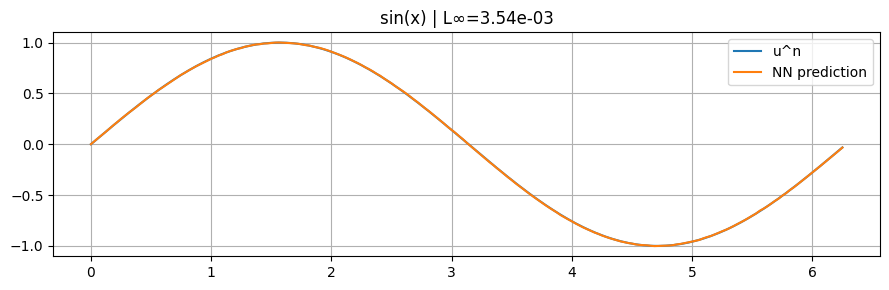

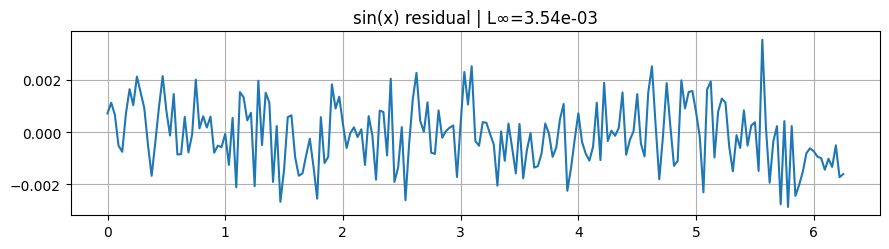

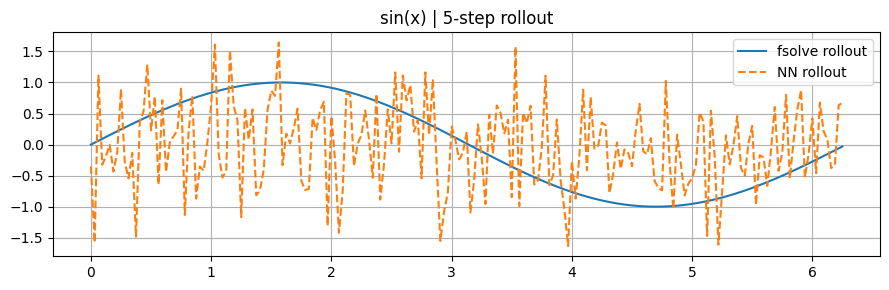


--- 0.5+0.25sin(x) ---
[test] 0.5+0.25sin(x) | L∞=3.042e-01 | Mean=8.633e-02
NN inference : 8.614 ms
fsolve solve : 18.285 ms
5-step rollout: 0.028 sec
Memory usage : 1598.48 MB


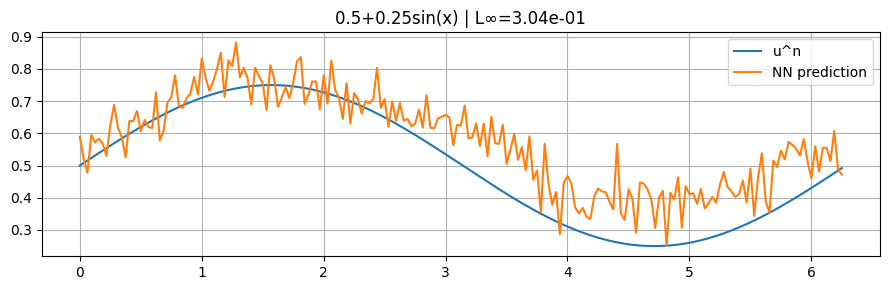

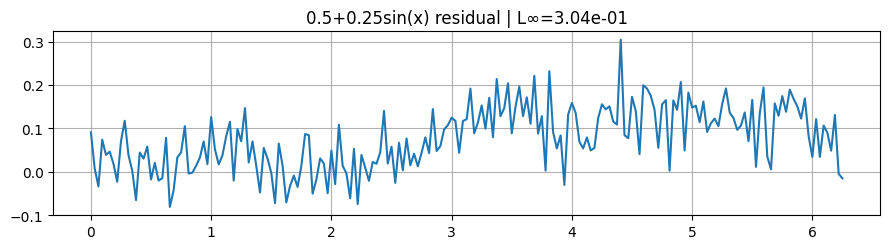

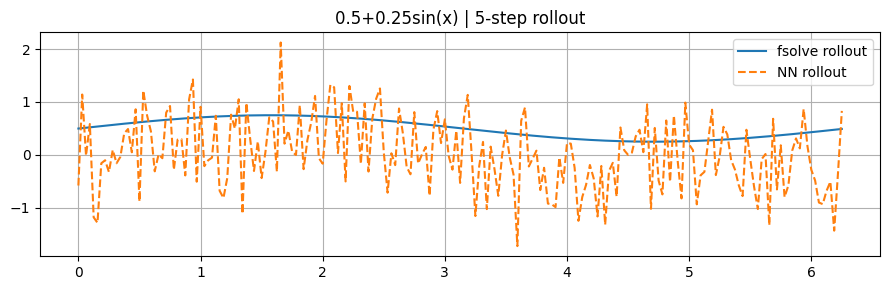


--- sin(sqrt(2)x) ---
[test] sin(sqrt(2)x) | L∞=1.365e-01 | Mean=4.228e-02
NN inference : 8.611 ms
fsolve solve : 18.287 ms
5-step rollout: 0.040 sec
Memory usage : 1602.29 MB


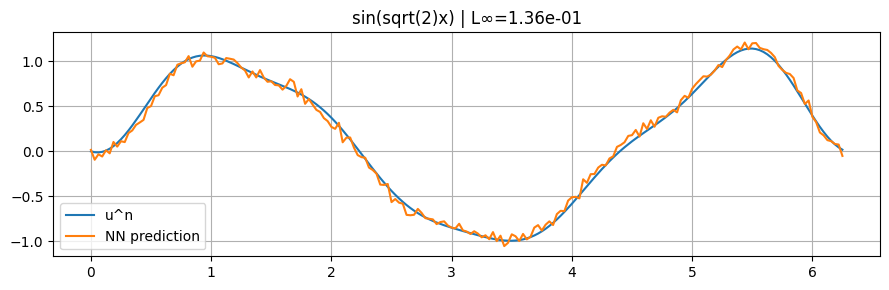

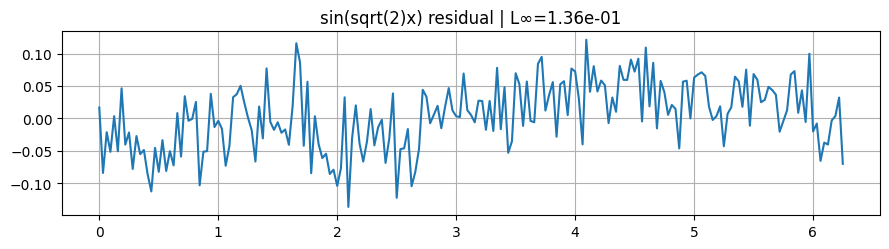

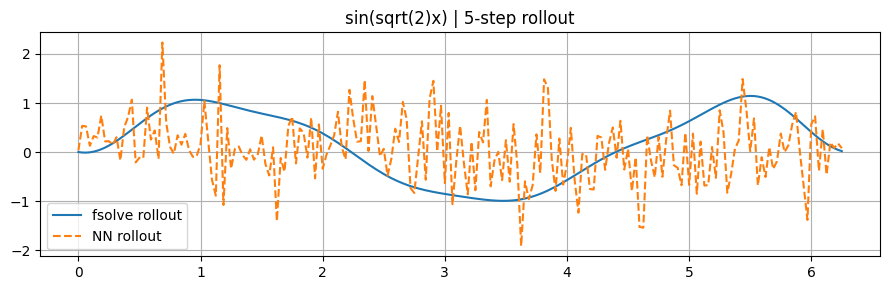


--- cos(sqrt(3)x) ---
[test] cos(sqrt(3)x) | L∞=2.552e-01 | Mean=8.855e-02
NN inference : 9.792 ms
fsolve solve : 15.360 ms
5-step rollout: 0.029 sec
Memory usage : 1604.54 MB


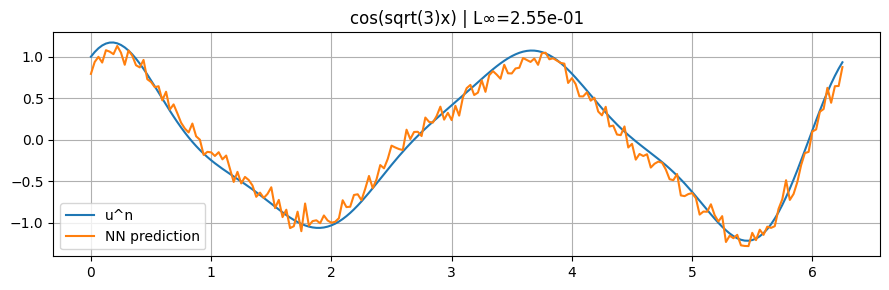

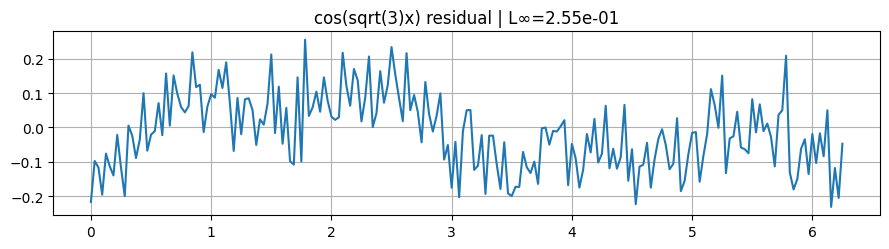

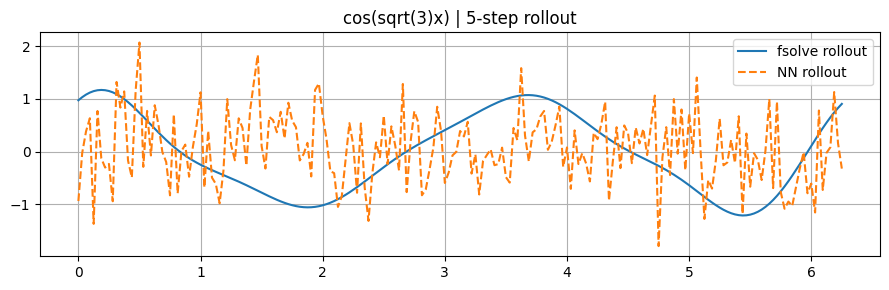


--- exp(-(x-pi)^2)*sin(sqrt(2)x) ---
[test] exp(-(x-pi)^2)*sin(sqrt(2)x) | L∞=5.802e-01 | Mean=1.705e-01
NN inference : 11.166 ms
fsolve solve : 36.032 ms
5-step rollout: 0.041 sec
Memory usage : 1607.90 MB


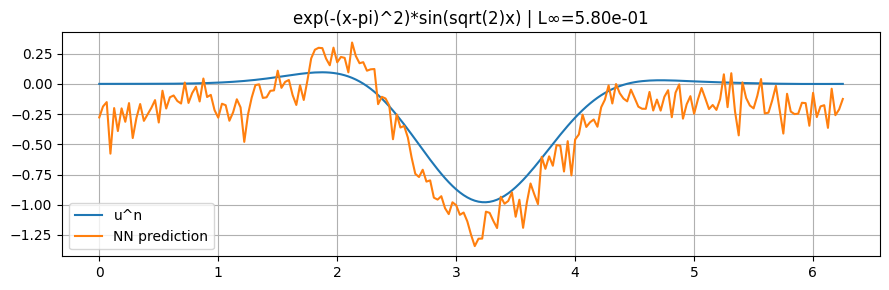

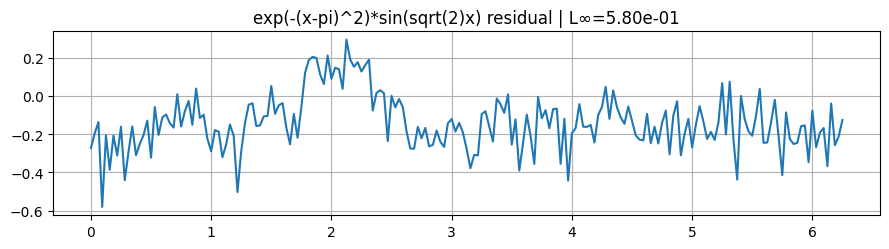

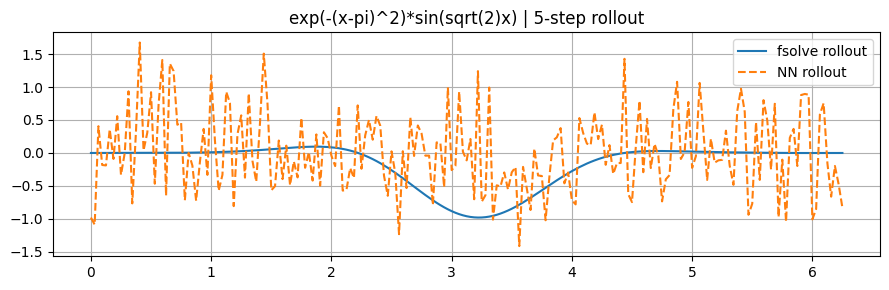


--- ((x-pi)^2)/(pi^2) ---
[test] ((x-pi)^2)/(pi^2) | L∞=2.216e-01 | Mean=6.881e-02
NN inference : 13.623 ms
fsolve solve : 32.557 ms
5-step rollout: 0.043 sec
Memory usage : 1610.98 MB


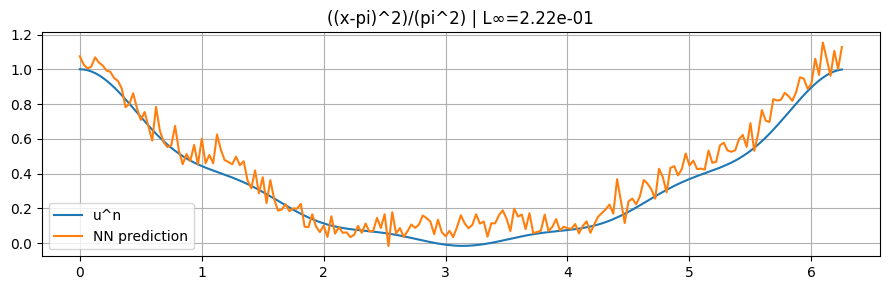

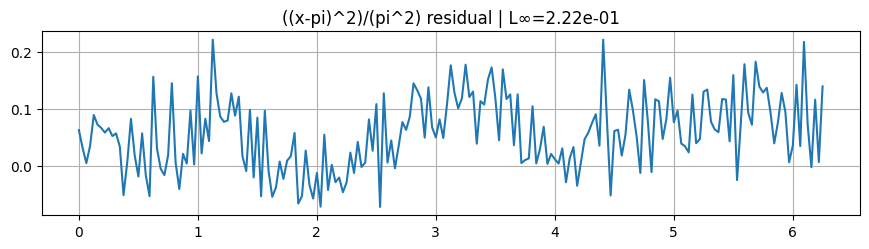

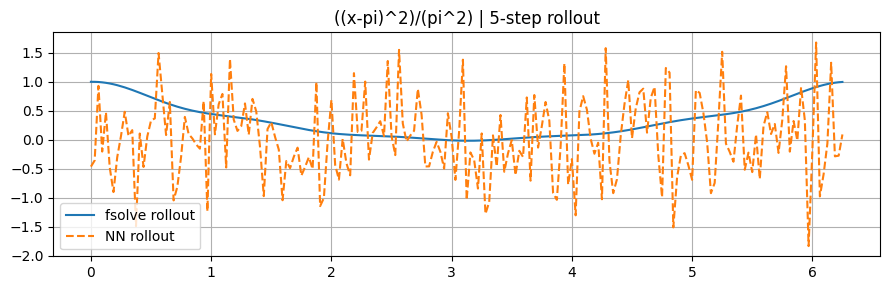


--- (pi^2-(x-pi)^2)/(pi^2) ---
[test] (pi^2-(x-pi)^2)/(pi^2) | L∞=3.733e-01 | Mean=1.123e-01
NN inference : 10.161 ms
fsolve solve : 34.325 ms
5-step rollout: 0.057 sec
Memory usage : 1615.80 MB


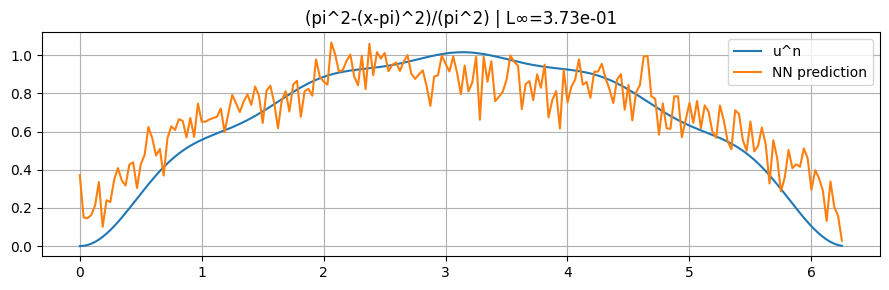

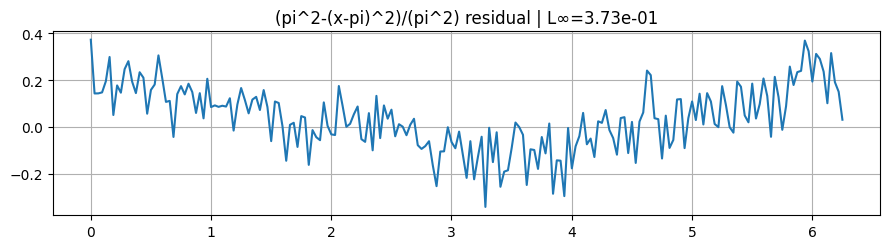

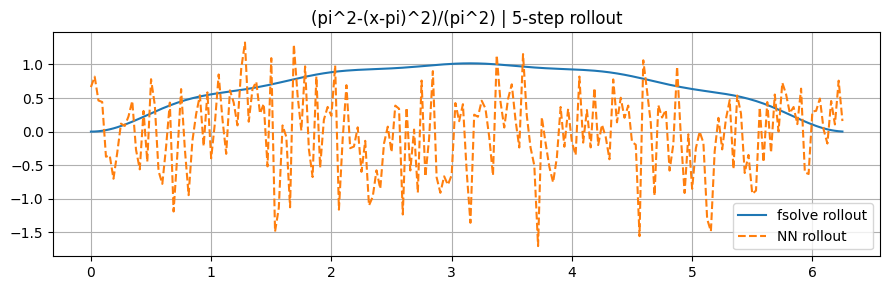


Saved summary CSV:
CaseA_DataOnly_0.005_results\testing_summary_0.005.csv

Plots saved in:
CaseA_DataOnly_0.005_results\plots


In [7]:
# TEST & DIAGNOStic
import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve

# Paths
OUT_DIR = "CaseA_DataOnly_0.005_results"

PLOTS_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseA_dataonly_0.005.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseA_dataonly_meta_0.005.npz"
)

CSV_FILE = os.path.join(
    OUT_DIR,
    "testing_summary_0.005.csv"
)

# Memory
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

# Load meta
meta = np.load(META_FILE, allow_pickle=True)

NX_FINE   = int(meta["NX_FINE"])

NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])

L  = float(meta["L"])

HIDDEN_UNITS = int(meta["HIDDEN_UNITS"])

DEPTH = int(meta["DEPTH"])

SIREN_W0 = float(meta["SIREN_W0"])

feat_mean = meta["feat_mean"]

feat_std = meta["feat_std"]

# Grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Diffferentiation matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)

# Residual
def residual_np(y, u):

    return y - u + 0.25*DT*(D_np @ (y**2))

# Fourier Interpolation
def fourier_interpolate(u_coarse, Nc, Nf):

    Uc = np.fft.fft(u_coarse)

    Uc_shift = np.fft.fftshift(Uc)

    pad_total = max(Nf-Nc, 0)

    pad_left = pad_total // 2

    pad_right = pad_total - pad_left

    Uc_padded_shift = np.pad(
        Uc_shift,
        (pad_left, pad_right),
        mode="constant"
    )

    Uc_padded = np.fft.ifftshift(
        Uc_padded_shift
    )

    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)

    return u_fine.real

# Fsolve
def compute_y1_fsolve(un):

    un = np.asarray(un, dtype=np.float64)

    N = un.size

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))

    y0 = un.copy()

    y_sol = fsolve(
        F,
        y0,
        fprime=J,
        xtol=1e-12
    )

    return y_sol.astype(np.float64)

# SIREN LAYER
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0/in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# Model
def build_model():

    input_dim = len(feat_mean)

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(inputs, outputs)

model = build_model()

_ = model(
    tf.zeros((1, len(feat_mean)), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("\nLoaded saved model.")

# SAFE FILENAME
def safe_filename(name):

    return (
        name.replace("(", "")
            .replace(")", "")
            .replace("*", "")
            .replace("^", "")
            .replace("+", "")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("=", "_")
            .replace(" ", "_")
    )

# Features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# Rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(feat, dtype=tf.float64),
            training=False
        ).numpy()[0]

        u = y.copy()

        traj.append(u.copy())

    return traj

# Testing function
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),

    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),
    # Normalised Polynomial
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) / (np.pi**2)
    )
]

summary = []

# Testing
print("\nTEST & DIAGNOSTICS")

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    # Initial conditions
    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # NN Prediciton TIMING
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # Fsolve timing
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Residual
    r = residual_np(y_pred, uf)

    Linf = float(np.max(np.abs(r)))

    Mean = float(np.mean(np.abs(r)))

    # Rollout timing
    steps = 5

    r0 = time.perf_counter()

    traj_nn = rollout_nn(uf, steps)

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # FSOLVE ROLLOUT
    traj_fs = [uf.copy()]

    tmp = uf.copy()

    for _ in range(steps):

        tmp = compute_y1_fsolve(tmp)

        traj_fs.append(tmp.copy())

    mem_now = memory_mb()

    print(
        f"[test] {name:12s} | "
        f"L∞={Linf:.3e} | "
        f"Mean={Mean:.3e}"
    )

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    xs = x_fine

    # Solution Plot
    plt.figure(figsize=(9,3))

    plt.plot(xs, uf, label="u^n")

    plt.plot(xs, y_pred, label="NN prediction")

    plt.legend()

    plt.title(f"{name} | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_nn.png"
        ),
        dpi=150
    )

    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))

    plt.plot(xs, r)

    plt.title(f"{name} residual | L∞={Linf:.2e}")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_res.png"
        ),
        dpi=150
    )

    plt.show()

    # Rollout plot
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        traj_fs[-1],
        label="fsolve rollout"
    )

    plt.plot(
        xs,
        traj_nn[-1],
        "--",
        label="NN rollout"
    )

    plt.legend()

    plt.title(f"{name} | {steps}-step rollout")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_rollout.png"
        ),
        dpi=150
    )

    plt.show()

    summary.append([

        name,

        Linf,

        Mean,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now
    ])
                   
# SAVE CSV
with open(CSV_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Linf",

        "MeanResidual",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB"
    ])

    writer.writerows(summary)

print("\nSaved summary CSV:")

print(CSV_FILE)

print("\nPlots saved in:")

print(PLOTS_DIR)